In [2]:
# importacmos librerías
import pandas as pd
import numpy as np
import glob
import geopandas as gpd
from shapely import wkt
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [3]:
# funciones auxiliares
def estandarizar_codi_barri(df, columna_barri):
    """Filtramos nulos y forzamos cod_barrio a entero (1-73) para merges."""
    df = df.dropna(subset=[columna_barri]).copy()
    df[columna_barri] = pd.to_numeric(df[columna_barri], errors='coerce')
    df = df.dropna(subset=[columna_barri])
    df[columna_barri] = df[columna_barri].astype(int)
    return df[(df[columna_barri] >= 1) & (df[columna_barri] <= 73)]


In [4]:
# cargamos dimensiones y diccionarios
df_dims = pd.read_csv('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\pad_dimensions.csv')


dicc_barris = df_dims[df_dims['Desc_Dimensio'] == 'CODI_BARRI_DEST'][['Codi_Valor', 'Desc_Valor_CA']].copy()
dicc_barris.rename(columns={'Codi_Valor': 'Codi_Barri', 'Desc_Valor_CA': 'Nom_Barri_Oficial'}, inplace=True)
dicc_barris['Codi_Barri'] = pd.to_numeric(dicc_barris['Codi_Barri'], errors='coerce')


dicc_educa = df_dims[df_dims['Desc_Dimensio'] == 'NIV_EDUCA_esta'][['Codi_Valor', 'Desc_Valor_CA']].copy()
dicc_educa.rename(columns={'Codi_Valor': 'NIV_EDUCA_esta', 'Desc_Valor_CA': 'Desc_Educa'}, inplace=True)
dicc_educa['NIV_EDUCA_esta'] = pd.to_numeric(dicc_educa['NIV_EDUCA_esta'], errors='coerce')


In [5]:
# 1. VUTs (Viviendas de Uso Turístico)

rutas_huts = sorted(glob.glob('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\huts\\*.csv'))
lista_df_huts = []

for ruta in rutas_huts:
    df_temp = pd.read_csv(ruta, encoding='latin1', on_bad_lines='skip', low_memory=False)
    df_temp['Any'] = int(os.path.basename(ruta)[0:4])
    
    # unificamos nombres de columnas
    df_temp.rename(columns={'BARRI': 'Nom_Barri', 'NOM_BARRI': 'Nom_Barri', 'CODI_BARRI': 'Codi_Barri'}, inplace=True)
    
    # gestionamos la columna de número de plazas asignando nulos (NaN) en vez de ceros para evitar sesgar los datos
    if 'NUMERO_PLACES' not in df_temp.columns:
        df_temp['NUMERO_PLACES'] = np.nan
    else:
        # errors='coerce' transforma automáticamente los errores de texto directamente a NaN
        df_temp['NUMERO_PLACES'] = pd.to_numeric(df_temp['NUMERO_PLACES'], errors='coerce')

    cols = [c for c in ['Any', 'N_EXPEDIENT', 'NUMERO_PLACES', 'Nom_Barri', 'Codi_Barri'] if c in df_temp.columns]
    lista_df_huts.append(df_temp[cols])

df_huts_raw = pd.concat(lista_df_huts, ignore_index=True)

# nos quedamos con la última foto del año 
df_huts_raw = df_huts_raw.drop_duplicates(subset=['Any', 'N_EXPEDIENT'], keep='last')

# mapeamos los códigos de barrio faltantes 
if 'Codi_Barri' in df_huts_raw.columns and 'Nom_Barri' in df_huts_raw.columns:
    df_huts_raw['Nom_Barri'] = df_huts_raw['Nom_Barri'].astype(str).str.upper().str.strip()
    mapeo = df_huts_raw.dropna(subset=['Codi_Barri', 'Nom_Barri']).drop_duplicates(subset=['Nom_Barri'])
    dicc_temp = dict(zip(mapeo['Nom_Barri'], mapeo['Codi_Barri']))
    df_huts_raw['Codi_Barri'] = df_huts_raw['Codi_Barri'].fillna(df_huts_raw['Nom_Barri'].map(dicc_temp))

# estandarizamos y agrupamos
df_huts_raw = estandarizar_codi_barri(df_huts_raw, 'Codi_Barri')
df_huts_final = df_huts_raw.groupby(['Any', 'Codi_Barri']).agg(
    Total_HUTs=('N_EXPEDIENT', 'count'),
    Places_HUTs=('NUMERO_PLACES', 'sum')
).reset_index()

In [6]:
# 2. PRECIO DEL ALQUILER

df_lloguer_raw = pd.read_csv('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\Tabla estadística.csv')

# pasamos de formato ancho a largo, filtrando solo por barrios
df_lloguer_melted = df_lloguer_raw[df_lloguer_raw['Tipo de territorio'] == 'Barri'].melt(
    id_vars=['Territorio', 'Tipo de territorio'], var_name='Trimestre_str', value_name='Preu_Lloguer_m2'
)

# limpiamos y estandarizamos datos
# 1. Cambiamos comas por puntos, guiones por nulos y convertimos a número
df_lloguer_melted['Preu_Lloguer_m2'] = pd.to_numeric(df_lloguer_melted['Preu_Lloguer_m2'].astype(str).str.replace(',', '.').replace('-', np.nan), errors='coerce')

# 2. ¡NUEVO! Sustituimos los ceros del Ayuntamiento por nulos (NaN) para que no bajen la media anual erróneamente
df_lloguer_melted['Preu_Lloguer_m2'] = df_lloguer_melted['Preu_Lloguer_m2'].replace(0, np.nan)

# extraemos el año
df_lloguer_melted['Any'] = df_lloguer_melted['Trimestre_str'].str[-4:].astype(int)

# calculamos media anual por barrio (Pandas ya ignora los NaN automáticamente en el .mean)
df_lloguer_grouped = df_lloguer_melted.groupby(['Any', 'Territorio'])['Preu_Lloguer_m2'].mean().reset_index()

# mergeamos con el diccionario para sacar el Codi_Barri
df_lloguer_final = pd.merge(df_lloguer_grouped, dicc_barris, left_on='Territorio', right_on='Nom_Barri_Oficial', how='inner')
df_lloguer_final = estandarizar_codi_barri(df_lloguer_final, 'Codi_Barri')[['Any', 'Codi_Barri', 'Preu_Lloguer_m2']]

In [7]:
# 3. NUM CONTRATOS ANUALES

# cargamos excel
df_contractes_raw = pd.read_excel('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\anual_bcn_contractes.xlsx', skiprows=3)
df_contractes_raw.rename(columns={'Codi': 'Codi_Barri_CSV', 'Unnamed: 1': 'Territori'}, inplace=True)

# recortamos dataframe para aislar sección de barrios
idx_barris = df_contractes_raw[df_contractes_raw['Territori'].astype(str).str.strip().str.startswith('Barris')].index[0]
df_contractes_barris = df_contractes_raw.iloc[idx_barris+1:].dropna(subset=['Codi_Barri_CSV']).copy()

# pasamos de formato ancho a largo y limpiamos 
df_contractes_melted = df_contractes_barris.melt(id_vars=['Codi_Barri_CSV', 'Territori'], var_name='Any_str', value_name='Num_Contractes')
df_contractes_melted['Any'] = pd.to_numeric(df_contractes_melted['Any_str'], errors='coerce')
df_contractes_melted['Num_Contractes'] = pd.to_numeric(df_contractes_melted['Num_Contractes'], errors='coerce')
df_contractes_melted = df_contractes_melted.dropna(subset=['Num_Contractes', 'Any'])

# estandarizamos el código de barrio
df_contractes_melted = estandarizar_codi_barri(df_contractes_melted, 'Codi_Barri_CSV')

# mergeamos con el diccionario y filtramos
df_contractes_final = pd.merge(df_contractes_melted, dicc_barris, left_on='Codi_Barri_CSV', right_on='Codi_Barri', how='inner')
df_contractes_final = df_contractes_final[['Any', 'Codi_Barri', 'Num_Contractes']].astype(int)

In [8]:
# 4. CALCULO POBLACIÓN

# cargamos y concatenamos todos los csv de la carpeta
df_naix_raw = pd.concat((pd.read_csv(f) for f in glob.glob('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\lloc_naix\\*_pad_mdbas_lloc-naix_sexe.csv')), ignore_index=True)

# extraemos el año de la fecha y limpiamos la columna de valores
df_naix_raw['Any'] = df_naix_raw['Data_Referencia'].astype(str).str[0:4].astype(int)

# CAMBIO 1: Quitamos el .fillna(0) aquí. Forzamos a número, y si hay errores, que se queden como NaN
df_naix_raw['Valor'] = pd.to_numeric(df_naix_raw['Valor'], errors='coerce')

# estandarizamos el código de barrio y agrupamos por lugar de nacimiento
df_naix = estandarizar_codi_barri(df_naix_raw, 'Codi_Barri')
df_naix_agg = df_naix.groupby(['Any', 'Codi_Barri', 'LLOC_NAIX'])['Valor'].sum().reset_index()

# calculamos la población total y filtramos la extranjera (códigos 4 y 5)
pob_total = df_naix_agg.groupby(['Any', 'Codi_Barri'])['Valor'].sum().reset_index(name='Poblacio_Total')
pob_ext = df_naix_agg[df_naix_agg['LLOC_NAIX'].isin([4, 5])].groupby(['Any', 'Codi_Barri'])['Valor'].sum().reset_index(name='Poblacio_Estrangera')

# unimos los totales
df_origen_final = pd.merge(pob_total, pob_ext, on=['Any', 'Codi_Barri'], how='left')

# CAMBIO 2: Sustituimos los 0s en Poblacio_Total por NaN para evitar "barrios fantasma" y divisiones entre cero
df_origen_final['Poblacio_Total'] = df_origen_final['Poblacio_Total'].replace(0, np.nan)

# Si Poblacio_Estrangera es nulo pero SÍ hay Población Total, significa que hay 0 extranjeros. Rellenamos solo esos
df_origen_final['Poblacio_Estrangera'] = df_origen_final['Poblacio_Estrangera'].fillna(0)

# calculamos el porcentaje de extranjeros (al dividir entre NaN, Pandas dejará el porcentaje también como NaN automáticamente)
df_origen_final['Pct_Estrangers'] = (df_origen_final['Poblacio_Estrangera'] / df_origen_final['Poblacio_Total']) * 100
df_origen_final = df_origen_final[['Any', 'Codi_Barri', 'Poblacio_Total', 'Pct_Estrangers']]

In [9]:
# 5. CÁLCULO UNIVERSITARIOS
# seguimos la misma lógica anterior

df_estudis_raw = pd.concat((pd.read_csv(f) for f in glob.glob('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\niv_educa\\*_pad_mdbas_niv-educa-esta_sexe.csv')), ignore_index=True)

df_estudis_raw['Any'] = df_estudis_raw['Data_Referencia'].astype(str).str[0:4].astype(int)
df_estudis_raw['Valor'] = pd.to_numeric(df_estudis_raw['Valor'], errors='coerce').fillna(0)

df_estudis_raw = estandarizar_codi_barri(df_estudis_raw, 'Codi_Barri')
df_estudis_agg = df_estudis_raw.groupby(['Any', 'Codi_Barri', 'NIV_EDUCA_esta'])['Valor'].sum().reset_index()

pob_total_est = df_estudis_agg.groupby(['Any', 'Codi_Barri'])['Valor'].sum().reset_index(name='Poblacio_Total')
pob_univ = df_estudis_agg[df_estudis_agg['NIV_EDUCA_esta'] == 5].groupby(['Any', 'Codi_Barri'])['Valor'].sum().reset_index(name='Poblacio_Universitaria')

df_estudis_final = pd.merge(pob_total_est, pob_univ, on=['Any', 'Codi_Barri'], how='left').fillna({'Poblacio_Universitaria': 0})
df_estudis_final['Pct_Universitaris'] = (df_estudis_final['Poblacio_Universitaria'] / df_estudis_final['Poblacio_Total']) * 100
df_estudis_final = df_estudis_final[['Any', 'Codi_Barri', 'Pct_Universitaris']]

In [10]:
# 6. NUM LOCALES ACTIVOS

llista_df_agg = []

# iteramos sobre los csv y extraemos el año del nombre del archivo
for archivo in glob.glob('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\cens_comercial\\*.csv'):
    match = re.search(r'(20\d{2})', archivo)
    if not match: continue
    
    # leemos el archivo
    df_temp = pd.read_csv(archivo, low_memory=False)
    
    # unificamos el filtro de locales activos según el esquema de cada año
    if 'CBARRI' in df_temp.columns:
        df_temp['Codi_Barri'] = df_temp['CBARRI']
        df_actius = df_temp[df_temp['BCN1'].astype(str).str.upper() != 'LOCAL BUIT'].copy()
    elif 'ID_PRINCIP' in df_temp.columns:
        df_actius = df_temp[df_temp['ID_PRINCIP'] == 1].copy()
    elif 'Codi_Principal_Activitat' in df_temp.columns:
        df_actius = df_temp[df_temp['Codi_Principal_Activitat'] == 1].copy()
    else: continue

    # estandarizamos el código de barrio y contamos el total de locales por barrio
    df_actius = estandarizar_codi_barri(df_actius, 'Codi_Barri')
    df_agg = df_actius.groupby('Codi_Barri').size().reset_index(name='Num_Locals_Actius')
    
    # asignamos el año correspondiente y lo añadimos a la lista
    df_agg['Any'] = int(match.group(1))
    llista_df_agg.append(df_agg)

# concatenamos todos los años y filtramos columnas finales
df_locals_final = pd.concat(llista_df_agg, ignore_index=True)[['Any', 'Codi_Barri', 'Num_Locals_Actius']]

In [11]:
# 7. RENTA BRUTA MEDIA

# cargamos y concatenamos todos los csv de la carpeta
df_renda_raw = pd.concat((pd.read_csv(f) for f in glob.glob('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\renda\\*.csv')), ignore_index=True)

# estandarizamos el código de barrio y forzamos a formato numérico
df_renda_raw = estandarizar_codi_barri(df_renda_raw, 'Codi_Barri')
df_renda_raw['Import_Renda_Bruta_€'] = pd.to_numeric(df_renda_raw['Import_Renda_Bruta_€'], errors='coerce')

# calculamos la media anual por barrio
df_renda_final = df_renda_raw.groupby(['Any', 'Codi_Barri'])['Import_Renda_Bruta_€'].mean().round(2).reset_index()

# renombramos la columna al formato final
df_renda_final.rename(columns={'Import_Renda_Bruta_€': 'Renda_Bruta_Mitjana'}, inplace=True)

In [25]:
# 8. MASTER DATASET 
# unimos todos los datasets

# Cross join para generar base 
df_master = pd.DataFrame({'Any': range(2014, 2025)}).merge(dicc_barris[['Codi_Barri', 'Nom_Barri_Oficial']].drop_duplicates(), how='cross')

# unimos todos los datasets ya limpios mediante left join  
df_master = pd.merge(df_master, df_huts_final, on=['Any', 'Codi_Barri'], how='left')
df_master = pd.merge(df_master, df_origen_final, on=['Any', 'Codi_Barri'], how='left')
df_master = pd.merge(df_master, df_estudis_final, on=['Any', 'Codi_Barri'], how='left')
df_master = pd.merge(df_master, df_lloguer_final, on=['Any', 'Codi_Barri'], how='left')
df_master = pd.merge(df_master, df_locals_final, on=['Any', 'Codi_Barri'], how='left')
df_master = pd.merge(df_master, df_renda_final, on=['Any', 'Codi_Barri'], how='left')
df_master = pd.merge(df_master, df_contractes_final, on=['Any', 'Codi_Barri'], how='left')

# forzamos tipos de datos correctos usando 'Int64' para soportar los valores nulos
df_master = df_master.astype({
    'Total_HUTs': 'Int64',
    'Places_HUTs': 'Int64',
    'Poblacio_Total': 'Int64',
    'Preu_Lloguer_m2': float,
    'Num_Locals_Actius': 'Int64'
})

# renombramos columnas
df_master.rename(columns={
    'Any': 'anyo', 'Codi_Barri': 'cod_barrio', 'Nom_Barri_Oficial': 'nom_barrio',
    'Total_HUTs': 'total_VUTs', 'Places_HUTs': 'plazas_VUTs', 'Poblacio_Total': 'poblacion_total',
    'Pct_Estrangers': 'pct_extranjeros', 'Pct_Universitaris': 'pct_universitarios',
    'Preu_Lloguer_m2': 'precio_alquiler_m2', 'Num_Locals_Actius': 'num_locales_activos',
    'Renda_Bruta_Mitjana': 'renta_bruta_media', 'Num_Contractes': 'num_contratos'
}, inplace=True)

df_master.sort_values(by=['anyo', 'cod_barrio'], inplace=True, ignore_index=True)

# exportamos
df_master.to_csv('../datasets/master_dataset_bcn.csv', sep=';', decimal=',', encoding='utf-8-sig', index=False)
df_master.to_parquet('../datasets/master_dataset_bcn.parquet', index=False)

df_master.head()

,anyo,cod_barrio,nom_barrio,total_VUTs,plazas_VUTs,poblacion_total,pct_extranjeros,pct_universitarios,precio_alquiler_m2,num_locales_activos,renta_bruta_media,num_contratos
0,2014,1,el Raval,<NA>,<NA>,<NA>,NaN,NaN,10.475,2297,NaN,1583
1,2014,2,el Barri Gòtic,<NA>,<NA>,<NA>,NaN,NaN,10.550,1936,NaN,630
2,2014,3,la Barceloneta,<NA>,<NA>,<NA>,NaN,NaN,15.125,639,NaN,566
3,2014,4,"Sant Pere, Santa Caterina i la Ribera",<NA>,<NA>,<NA>,NaN,NaN,11.225,1680,NaN,982
4,2014,5,el Fort Pienc,<NA>,<NA>,<NA>,NaN,NaN,9.975,938,NaN,910


In [26]:
# 9. GEODATAFRAME PARA MAPAS

df_barris = pd.read_csv('C:\\Users\\alba_\\OneDrive\\Documentos\\1-MASTER\\1TFM\\datasets\\BarcelonaCiutat_Barris.csv')
df_barris['codi_barri'] = df_barris['codi_barri'].astype(int)

# unimos el master dataset con los datos espaciales
df_merged = pd.merge(df_master, df_barris, left_on='cod_barrio', right_on='codi_barri', how='left')

# convertimos geometry en objetos espaciales procesables
df_merged['geometry'] = df_merged['geometria_wgs84'].apply(wkt.loads)

# creamos el geodataframe asignando la columna geometry y el sistema de coordenadas
gdf_master = gpd.GeoDataFrame(df_merged, geometry='geometry', crs="EPSG:4326")

# exportamos a geojson
gdf_master.to_file("../datasets/gdf_master.geojson", driver="GeoJSON")

In [30]:
# filtramos los datos del año inicial y final para las variables clave
df_inicio = df_master[df_master['anyo'] == 2018][['cod_barrio', 'precio_alquiler_m2', 'pct_extranjeros', 'total_VUTs']].set_index('cod_barrio')
df_fin = df_master[df_master['anyo'] == 2023][['cod_barrio', 'precio_alquiler_m2', 'pct_extranjeros', 'total_VUTs']].set_index('cod_barrio')

# sustituimos los 0 por NaN para evitar divisiones por cero al calcular el delta
df_inicio_safe = df_inicio.replace(0, np.nan)

# calculamos la variación porcentual (delta) de cada variable
df_delta = ((df_fin - df_inicio_safe) / df_inicio_safe) * 100

# rellenamos los nulos generados y renombramos las columnas
df_delta = df_delta.fillna(0)
df_delta.columns = ['delta_alquiler', 'delta_extranjeros', 'delta_vuts']

# calculamos la media de la ciudad para establecer los umbrales de comparación
media_bcn_alquiler = df_delta['delta_alquiler'].mean()
media_bcn_extranjeros = df_delta['delta_extranjeros'].mean()
media_bcn_vuts = df_delta['delta_vuts'].mean()

# aplicamos las reglas de negocio y sumamos cuántas condiciones cumple cada barrio
condicion_1 = df_delta['delta_alquiler'] > media_bcn_alquiler
condicion_2 = df_delta['delta_extranjeros'] > media_bcn_extranjeros
condicion_3 = df_delta['delta_vuts'] > media_bcn_vuts 
df_delta['puntos_riesgo'] = condicion_1.astype(int) + condicion_2.astype(int) + condicion_3.astype(int)

# creamos la variable objetivo asignando riesgo (1) si el barrio cumple al menos 2 de las 3 condiciones
df_delta['riesgo_gentrificacion'] = np.where(df_delta['puntos_riesgo'] >= 2, 1, 0)
df_riesgo_final = df_delta.reset_index()

# exportamos el dataframe resultante a csv y mostramos los primeros registros
df_riesgo_final.to_csv('../datasets/riesgo_gentri3.csv', sep=';', decimal=',', encoding='utf-8-sig', index=False)

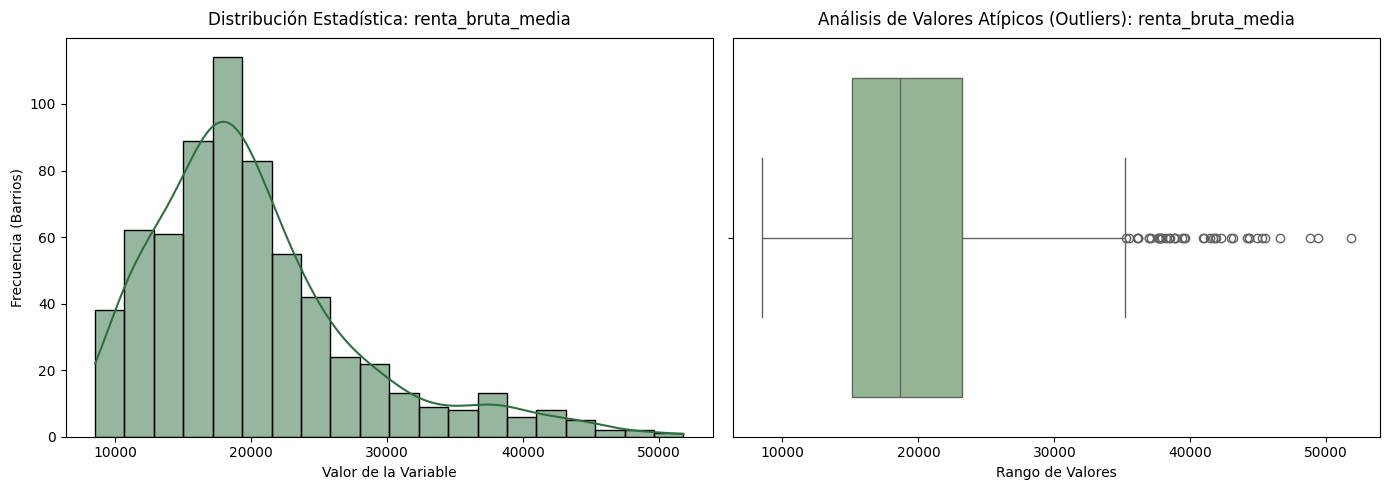

In [14]:
# visualización EDA
variable_analizar = 'renta_bruta_media' 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma para ver la Distribución
sns.histplot(df_master[variable_analizar], kde=True, ax=axes[0], color='#2e6f40', bins=20)
axes[0].set_title(f'Distribución Estadística: {variable_analizar}', fontsize=12, pad=10)
axes[0].set_xlabel('Valor de la Variable')
axes[0].set_ylabel('Frecuencia (Barrios)')

# Boxplot para identificar Outliers
sns.boxplot(x=df_master[variable_analizar], ax=axes[1], color='#8fbc8f')
axes[1].set_title(f'Análisis de Valores Atípicos (Outliers): {variable_analizar}', fontsize=12, pad=10)
axes[1].set_xlabel('Rango de Valores')

plt.tight_layout()
plt.show()

# Modelado

In [15]:
# 10. ML - FASE 1: TARGET CREATION (K-MEANS)

# calculamos la variación porcentual (delta) de cada variable clave entre 2018 y 2023 para cada barrio
df_inicio = df_master[df_master['anyo'] == 2018].set_index('cod_barrio')[['precio_alquiler_m2', 'pct_extranjeros', 'total_VUTs']]
df_fin = df_master[df_master['anyo'] == 2023].set_index('cod_barrio')[['precio_alquiler_m2', 'pct_extranjeros', 'total_VUTs']]

# sustituimos los 0 por NaN para evitar divisiones por cero, y luego calculamos el delta
df_delta = ((df_fin - df_inicio.replace(0, np.nan)) / df_inicio.replace(0, np.nan)) * 100
df_delta = df_delta.fillna(0)
df_delta.columns = ['delta_alquiler', 'delta_extranjeros', 'delta_vuts']

# aplicamos winsorización al percentil 95 para limitar el impacto de los outliers en el clustering
for col in df_delta.columns:
    df_delta[col] = np.clip(df_delta[col], a_min=None, a_max=df_delta[col].quantile(0.95))

# escalamos las variables con RobustScaler y agrupamos con K-Means (3 clusters para tener 3 grupos, uno de alto riesgo, otro intermedio y otro bajo riesgo)
df_delta['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(RobustScaler().fit_transform(df_delta))

# asignamos el valor 1 al cluster que tenga mayor riesgo de gentrificación
cluster_riesgo = 1
df_delta['riesgo_gentrificacion'] = np.where(df_delta['cluster'] == cluster_riesgo, 1, 0)
df_riesgo_final = df_delta.reset_index()



In [20]:
# 11. ML - FASE 2 & 3: RANDOM FOREST PREDICTION

# 1. Definimos las features primero para poder usarlas al filtrar
features = [
    'precio_alquiler_m2', 
    'pct_extranjeros', 
    'total_VUTs', 
    'pct_universitarios',  
    'num_locales_activos',
    'poblacion_total',
    'plazas_VUTs',
    'num_contratos'
]

# 2. Preparamos el dataset de entrenamiento con datos de 2018
# Usamos ['cod_barrio', 'nom_barrio'] + features para traernos todas las columnas de golpe
columnas_necesarias = ['cod_barrio', 'nom_barrio'] + features

df_train = pd.merge(
    df_master[df_master['anyo'] == 2018][columnas_necesarias],
    df_riesgo_final[['cod_barrio', 'riesgo_gentrificacion']], 
    on='cod_barrio'
)

# 3. Definimos las variables predictoras (X) y el objetivo (y)
X_train = df_train[features]
y_train = df_train['riesgo_gentrificacion']

# 4. Entrenamos el modelo Random Forest con 100 árboles de decisión
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 5. Preparamos los datos de 2023 para realizar la predicción de riesgo actual
df_pred_full = df_master[df_master['anyo'] == 2023][columnas_necesarias]

# 6. Calculamos las probabilidades de pertenecer al clúster de riesgo
X_to_predict = df_pred_full[features]
probs = rf.predict_proba(X_to_predict)[:, 1]

# 7. Generamos el dataframe final
df_resultados = df_pred_full[['cod_barrio', 'nom_barrio']].copy()
df_resultados['prob_gentrificacion_%'] = (probs * 100).round(2)

# Ordenamos y mostramos
print("\n--- TOP 10 BARRIOS EN RIESGO DE GENTRIFICACIÓN (PROYECCIÓN 2023) ---")
ranking = df_resultados.sort_values(by='prob_gentrificacion_%', ascending=False).head(10)
print(ranking.to_string(index=False))


--- TOP 10 BARRIOS EN RIESGO DE GENTRIFICACIÓN (PROYECCIÓN 2023) ---
 cod_barrio                            nom_barrio  prob_gentrificacion_%
         27                  el Putxet i el Farró                   59.0
         26                Sant Gervasi - Galvany                   59.0
         60                           Sant Andreu                   59.0
          9        la Nova Esquerra de l'Eixample                   57.0
          3                        la Barceloneta                   57.0
         23                                Sarrià                   56.0
         31                     la Vila de Gràcia                   55.0
         25            Sant Gervasi - la Bonanova                   55.0
          4 Sant Pere, Santa Caterina i la Ribera                   53.0
         24                       les Tres Torres                   50.0


C:\Users\alba_\AppData\Local\Temp\ipykernel_31996\3401750730.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='mako')


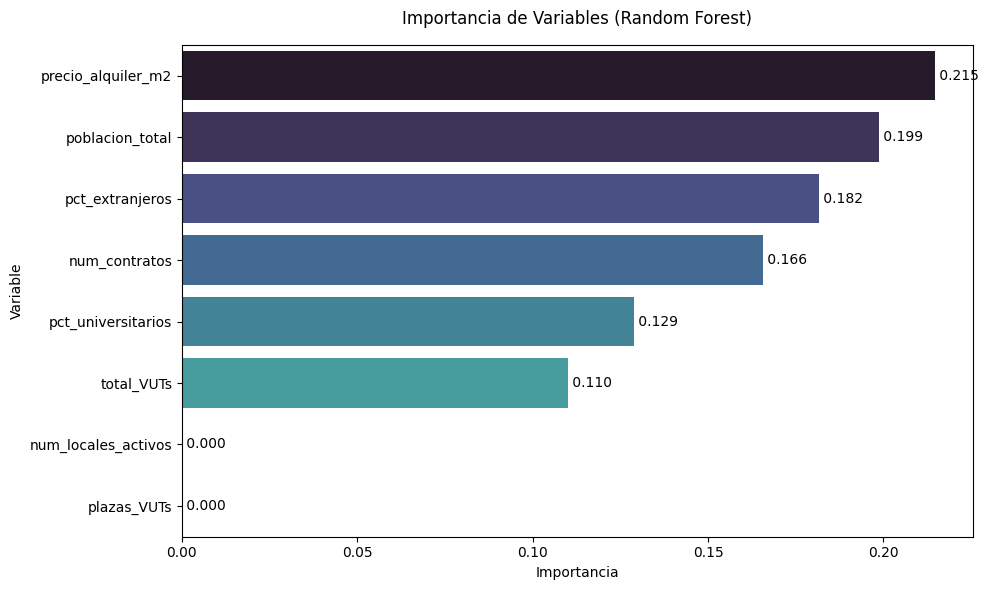

In [21]:
# 12. FEATURE IMPORTANCE

# extraemos la importancia de las caracteristicas del modelo y ordenamos
df_imp = pd.DataFrame({'Variable': X_train.columns, 'Importancia': rf.feature_importances_}).sort_values('Importancia', ascending=False)

# creamos gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='mako')
plt.title('Importancia de Variables (Random Forest)', pad=15)

# bucle for para iterar sobre los valores y añadir etiquetas con el valor de importancia al lado de cada barra
for idx, val in enumerate(df_imp['Importancia']):
    plt.text(val, idx, f' {val:.3f}', va='center')

# mostramos el gráfico
plt.tight_layout()
plt.show()